# FVCOM UGRID mesh — xugrid vs xpublish-tiles

Compares rendering of the Machias Bay FVCOM test fixture using:
- **xugrid** — reference plot directly on the UGRID mesh
- **xpublish-tiles** — raster tile render at zoom levels 9, 10, 11

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import xugrid as xu
from pathlib import Path

NC = Path("/home/rsignell/xpublish-tiles/src/xpublish_tiles/testing/grids/machias_bay_fvcom.nc")
EXTENT = (-67.63, -67.05, 44.48, 44.76)  # west, east, south, north

## 1 — xugrid reference

ERROR 1: PROJ: proj_create_from_database: Open of /home/rsignell/miniforge3/envs/protocoast-notebook/share/proj failed


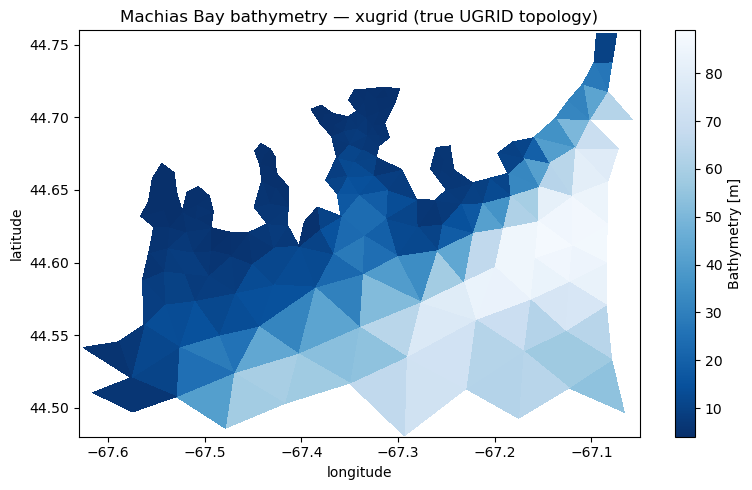

In [2]:
uds = xu.open_dataset(str(NC), mask_and_scale=False)

fig, ax = plt.subplots(figsize=(8, 5))
uds["h"].ugrid.plot(ax=ax, cmap="viridis", add_colorbar=True)
ax.set_title("Machias Bay bathymetry — xugrid (true UGRID topology)")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
west, east, south, north = EXTENT
ax.set_xlim(west, east)
ax.set_ylim(south, north)
plt.tight_layout()
plt.show()

## 2 — xpublish-tiles tile render

Renders tiles via the xpublish-tiles pipeline (subprocess into the project venv).

In [3]:
import subprocess, json

TILES = ["9/160/184", "10/320/369", "11/641/739"]

script = """
import sys, asyncio, json
sys.path.insert(0, "/home/rsignell/xpublish-tiles/src")
sys.path.insert(0, "/home/rsignell/xpublish-tiles/tests")

import morecantile
from xpublish_tiles.testing.datasets import FVCOM_MACHIAS_BAY
from xpublish_tiles.pipeline import pipeline
from tests import create_query_params

tms = morecantile.tms.get("WebMercatorQuad")
ds = FVCOM_MACHIAS_BAY.create()

async def render_all():
    paths = {}
    for tile_str in ["9/160/184", "10/320/369", "11/641/739"]:
        z, x, y = map(int, tile_str.split("/"))
        tile = morecantile.Tile(x, y, z)
        params = create_query_params(tile, tms)
        buf = await pipeline(ds, params)
        path = f"/tmp/fvcom_{tile_str.replace('/', '_')}.png"
        with open(path, "wb") as f:
            f.write(buf.getvalue())
        paths[tile_str] = path
    return paths

print(json.dumps(asyncio.run(render_all())))
"""

r = subprocess.run(
    ["/home/rsignell/xpublish-tiles/.venv/bin/python", "-c", script],
    capture_output=True, text=True, cwd="/home/rsignell/xpublish-tiles",
)
if r.returncode != 0:
    print(r.stderr[-3000:])
else:
    tile_paths = json.loads(r.stdout.strip().split("\n")[-1])
    print("Tiles saved:", tile_paths)

Tiles saved: {'9/160/184': '/tmp/fvcom_9_160_184.png', '10/320/369': '/tmp/fvcom_10_320_369.png', '11/641/739': '/tmp/fvcom_11_641_739.png'}


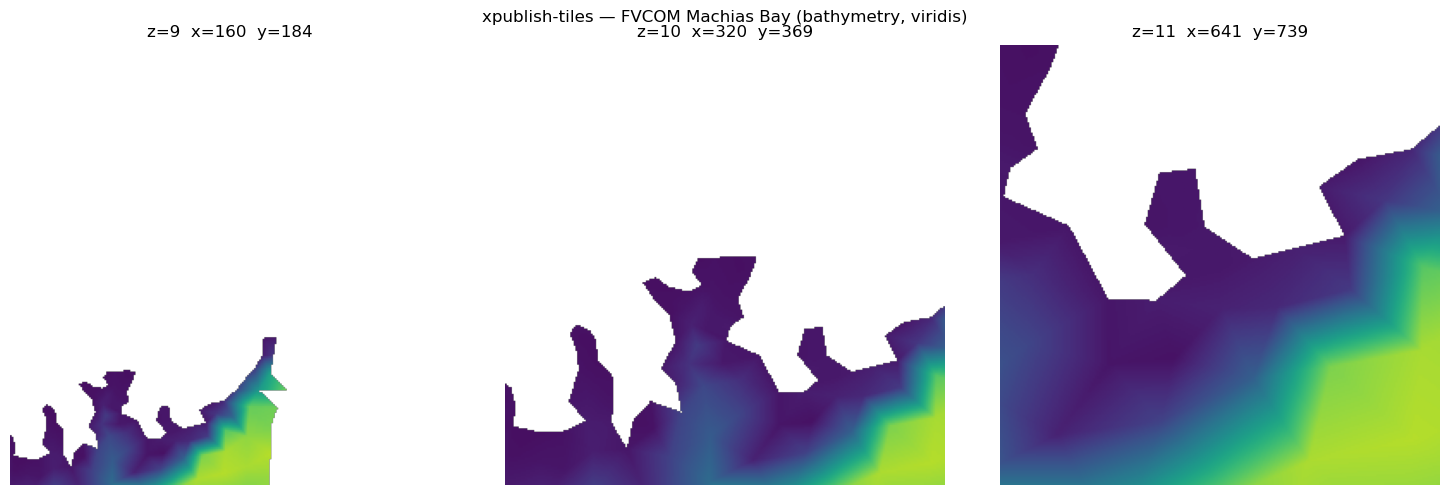

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, tile_str in zip(axes, TILES):
    img = mpimg.imread(tile_paths[tile_str])
    ax.imshow(img)
    z, x, y = tile_str.split("/")
    ax.set_title(f"z={z}  x={x}  y={y}")
    ax.axis("off")
plt.suptitle("xpublish-tiles — FVCOM Machias Bay (bathymetry, viridis)")
plt.tight_layout()
plt.show()

## 3 — Side-by-side: xugrid vs stitched zoom-11 tiles

Renders all zoom-11 tiles covering the full Machias Bay extent and geo-references them alongside the xugrid plot.

In [5]:
script = """
import sys, asyncio, json
sys.path.insert(0, "/home/rsignell/xpublish-tiles/src")
sys.path.insert(0, "/home/rsignell/xpublish-tiles/tests")

import morecantile
from xpublish_tiles.testing.datasets import FVCOM_MACHIAS_BAY
from xpublish_tiles.pipeline import pipeline
from tests import create_query_params

tms = morecantile.tms.get("WebMercatorQuad")
ds = FVCOM_MACHIAS_BAY.create()
bbox = (-67.63, 44.48, -67.05, 44.76)
tiles = list(tms.tiles(*bbox, zooms=11))

async def render_all():
    result = {}
    for tile in tiles:
        params = create_query_params(tile, tms)
        buf = await pipeline(ds, params)
        path = f"/tmp/fvcom_z11_{tile.x}_{tile.y}.png"
        with open(path, "wb") as f:
            f.write(buf.getvalue())
        bounds = tms.bounds(tile)
        result[f"{tile.z}/{tile.x}/{tile.y}"] = {"path": path, "bounds": list(bounds)}
    return result

print(json.dumps(asyncio.run(render_all())))
"""

r = subprocess.run(
    ["/home/rsignell/xpublish-tiles/.venv/bin/python", "-c", script],
    capture_output=True, text=True, cwd="/home/rsignell/xpublish-tiles",
)
if r.returncode != 0:
    print(r.stderr[-3000:])
else:
    z11_tiles = json.loads(r.stdout.strip().split("\n")[-1])
    print(f"Rendered {len(z11_tiles)} zoom-11 tiles")

Rendered 12 zoom-11 tiles


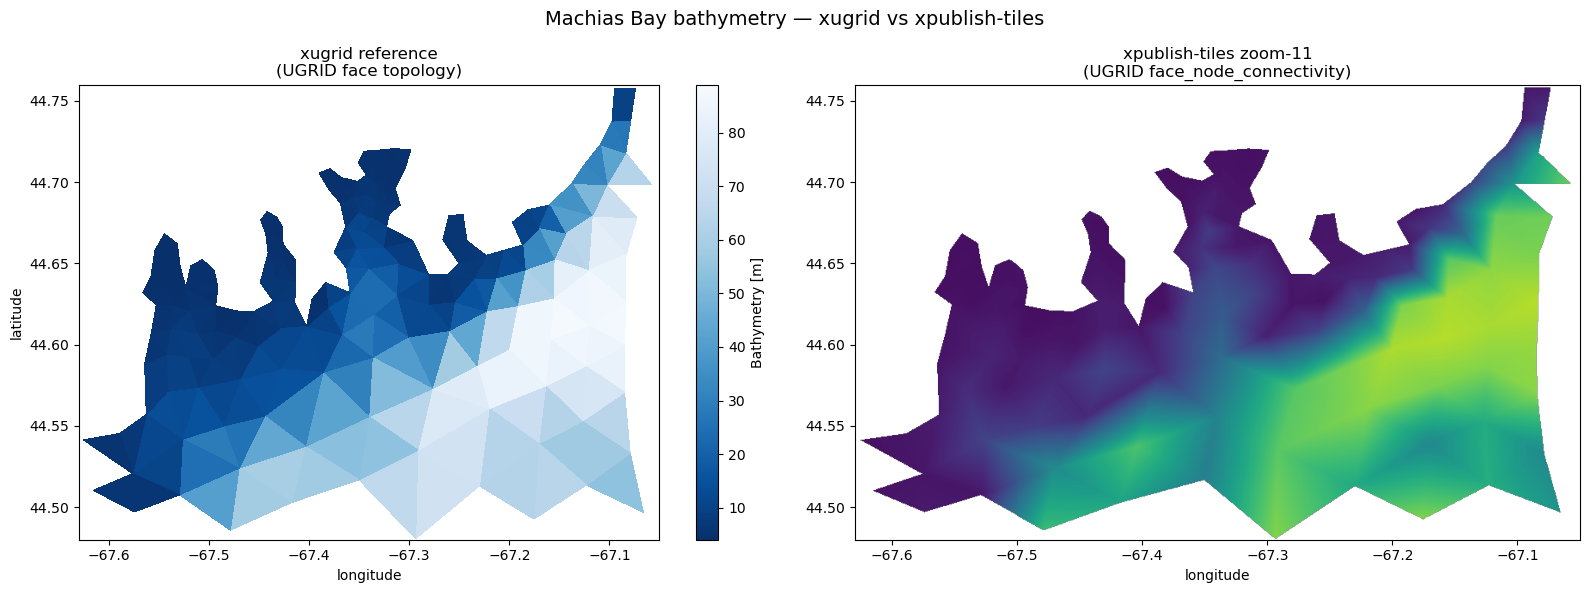

In [6]:
west, east, south, north = EXTENT

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: xugrid reference
uds["h"].ugrid.plot(ax=axes[0], cmap="viridis", add_colorbar=True)
axes[0].set_title("xugrid reference\n(UGRID face topology)", fontsize=12)
axes[0].set_xlabel("longitude")
axes[0].set_ylabel("latitude")
axes[0].set_xlim(west, east)
axes[0].set_ylim(south, north)

# Right: stitched zoom-11 tiles
for info in z11_tiles.values():
    img = mpimg.imread(info["path"])
    b = info["bounds"]  # [west, south, east, north]
    axes[1].imshow(img, extent=[b[0], b[2], b[1], b[3]], aspect="auto", origin="upper")
axes[1].set_title("xpublish-tiles zoom-11\n(UGRID face_node_connectivity)", fontsize=12)
axes[1].set_xlabel("longitude")
axes[1].set_xlim(west, east)
axes[1].set_ylim(south, north)

plt.suptitle("Machias Bay bathymetry — xugrid vs xpublish-tiles", fontsize=14)
plt.tight_layout()
plt.show()